In [1]:
import cmocean
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import warnings
from pathlib import Path

import pycompo.core.composite as pccompo
import pycompo.core.utils as pcutil
import pycompo.core.plot as pcplot
import pycompo.core.sigtest as pcsig

import hfplot.figure.figure as hffig
from hfplot.settings import STYLES

warnings.filterwarnings(action='ignore')

# read in configuration file
ana_idf = "ngc5004_opv4_w1"
config_file = f"/home/m/m300738/libs/pycompo/config/settings_{ana_idf}.yaml"
config = pcutil.read_yaml_config(config_file)
ana_times = pcutil.create_analysis_times(config)

### Read in composites

In [2]:
inpath = Path(f"{config['data']['outpath']}/{ana_idf}/")

infile_compo = Path(f"{ana_idf}_composite_rainbelt_bg_sfcwind_binned.nc")
rb_compo = xr.open_dataset(str(inpath/infile_compo))
rb_compo = pccompo.adjust_units(rb_compo, rb_compo.data_vars)

# read in p-values and calculate field significance
try:
    infile_pvalue = Path(f"{ana_idf}_pvalue_rainbelt_bg_sfcwind_binned.nc")
    rb_pvalue = xr.open_dataset(str(inpath/infile_pvalue))
    rb_sigmask = pcsig.get_field_significance(rb_pvalue, alpha_FDR=0.1)
except:
    pass

# read in feature_props
infile = Path(f"{ana_idf}_feature_props_rainbelt_all.nc")
rb_featprops = xr.open_dataset(str(inpath/infile))

### Correct composites by population means

In [3]:
ipath_popms = Path(f"{config['data']['outpath']}/{ana_idf}/popmeans/")

rb_popmeans = []
for start_time, end_time in zip(ana_times, ana_times[1:]):
    fdate_str = pcutil.create_ftime_str(start_time, end_time)
    ifile = Path(f"{ana_idf}_popmeans_rainbelt_{fdate_str}.nc")
    rb_popmeans.append(
        xr.open_dataset(ipath_popms/ifile).mean(dim='time').compute()
        )
    
rb_popmeans = xr.concat(rb_popmeans, dim='time').mean(dim="time")
rb_popmeans = pccompo.adjust_units(rb_popmeans, rb_popmeans.data_vars)

rb_compo_corrected = rb_compo - rb_popmeans

### Plotting

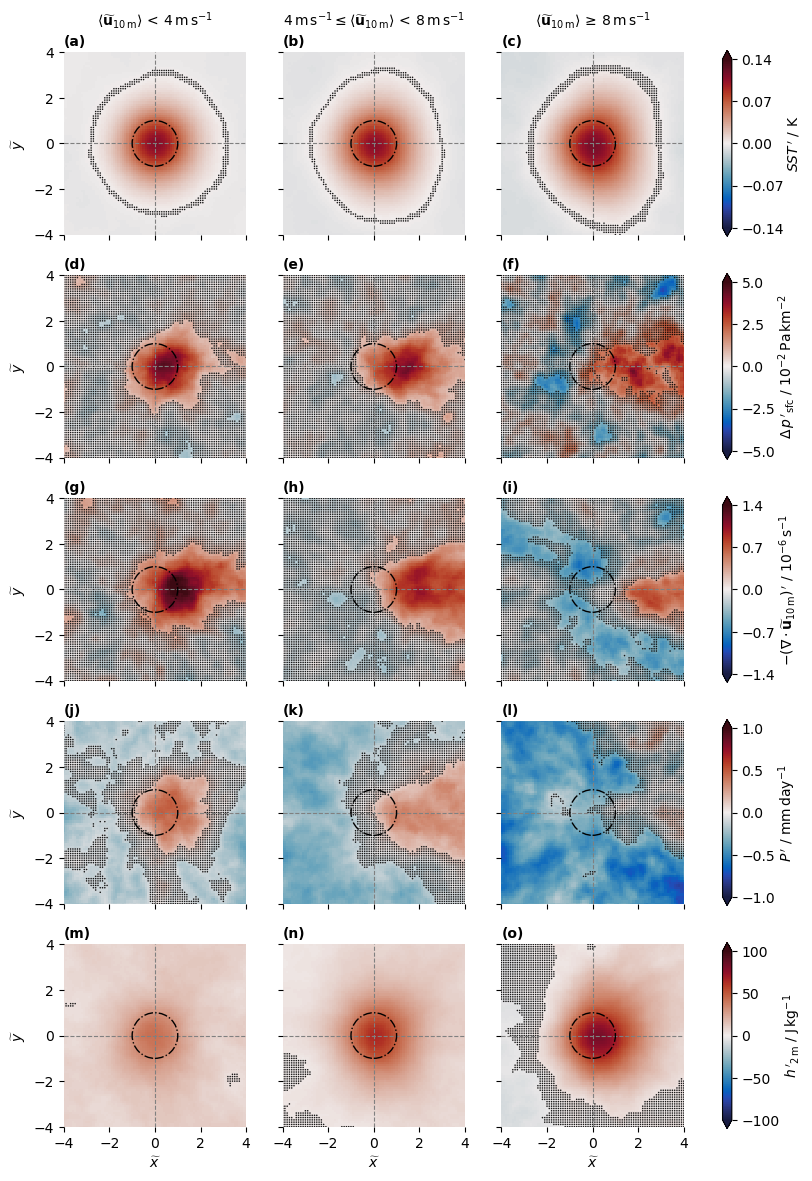

In [6]:
# User settings
CRANGE = {
    'ts_ano': [-0.14, 0.14],
    'tas_ano_laplacian': [-0.6, 0.6],
    'mse_sfc_ano': [-100, 100],
    'ps_ano_laplacian': [-5, 5],
    'sfcwind_conv_ano': [-1.4, 1.4],
    'pr_ano': [-1.0, 1.0],
}
CLABEL = {
    'ts_ano': "$SST\,\mathrm{'}$ / K",
    'tas_ano_laplacian': "$\Delta\,T\,\mathrm{'}_{\mathrm{2\,m}}$",
    'mse_sfc_ano': "$h\,\mathrm{'}_{\mathrm{2\,m}}$ / $\mathrm{J}\,\mathrm{kg}^{-1}$",
    'ps_ano_laplacian': "$\Delta\,p\,\mathrm{'}_{\mathrm{sfc}}$ / $10^{-2}\,\mathrm{Pa\,km^{-2}}$",
    'sfcwind_conv_ano': "$-\left(\\nabla\cdot\mathbf{\\widetilde{u}}_{\mathrm{10\,m}}\\right)\,\mathrm{'}$ / $10^{-6}\,\mathrm{s^{-1}}$",
    'pr_ano': "$P\,\mathrm{'}$ / $\mathrm{mm\,day^{-1}}$",
}

TITLES = {
    'bin_bg_sfcwind_0.0-4.0': '$\left\langle\\mathbf{\\widetilde{u}}_{\mathrm{10\,m}}\\right\\rangle\\,<\\,4\,\mathrm{m\,s^{-1}}$\n',
    'bin_bg_sfcwind_4.0-8.0': '$4\,\mathrm{m\,s^{-1}}\\leq\left\langle\\mathbf{\\widetilde{u}}_{\mathrm{10\,m}}\\right\\rangle\\,<\\,8\,\mathrm{m\,s^{-1}}$\n',
    'bin_bg_sfcwind_8.0-100.0': '$\left\langle\\mathbf{\\widetilde{u}}_{\mathrm{10\,m}}\\right\\rangle\\,\\geq\\,8\,\mathrm{m\,s^{-1}}$\n',
}

VARLIST = ['ts_ano', 'ps_ano_laplacian', 'sfcwind_conv_ano', 'pr_ano', 'mse_sfc_ano',]

# Plotting
fig, axes = hffig.init_subfig(
    style=None, asprat=(10, 14), nrow=5, ncol=3, sharex=True, sharey=True,
    )

for i, bin in enumerate(rb_compo_corrected['bin']):
    plot_data = rb_compo_corrected.sel(bin=bin)
    x = plot_data['En_rota2_featcen_x']
    y = plot_data['En_rota2_featcen_y']
    for j, var in enumerate(VARLIST):
        pl = axes[j, i].pcolormesh(
            x, y, plot_data[var].transpose(),
            vmin=CRANGE[var][0], vmax=CRANGE[var][1], cmap=cmocean.cm.balance,
            )
        
        pcplot.plot_sigmask(axes[j, i], rb_sigmask[var].sel(bin=bin))
        pcplot.plot_feature_grid(axes[j, i], x, y)
        pcplot.plot_feature_circle(axes[j, i], (0, 0), 1, lw=1)

        axes[j, i].set_aspect('equal')
        for spine in axes[j, i].spines.values():
            spine.set_visible(False)
        if i == 2:
            cb = fig.colorbar(
                pl, ax=axes[j, :], orientation='vertical', extend='both',
                ticks=np.linspace(CRANGE[var][0], CRANGE[var][1], 5),
                )
            cb.set_label(label=CLABEL[var], labelpad=1)

    axes[0, i].set_title(TITLES[str(bin.values)], fontsize=10)

# Make plot nice
hffig.set_limit(axes, [-4, 4], [-4, 4])
hffig.set_ticks(axes, [-4, -2, 0, 2, 4], [-4, -2, 0, 2, 4])
hffig.set_label(axes, '$\\widetilde{x}$', '$\\widetilde{y}$')

# Save plot
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figure07.png')
plt.savefig(str(outpath/outfile), dpi=600, bbox_inches='tight')
plt.show()